# Process 0 Generator: Autoclaving Event Log

This notebook builds a discrete-event simulation for an autoclaving process and generates an event log in the format expected by the pipeline:

- case_id
- activity
- timestamp_start
- timestamp_end
- object
- object_type
- higher_level_activity
- object_attributes

Flow per batch:
1. Filling
2. Sterilize on one of 2 machines (prepare -> heat -> hold -> cool -> clean)
3. Packaging on one station

In [1]:
import simpy
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

RANDOM_SEED = 42
N_BATCHES = 250
MEAN_INTERARRIVAL_MIN = 22.0
SIM_START = pd.Timestamp("2026-01-01 06:00:00")

rng = np.random.default_rng(RANDOM_SEED)

In [2]:
events = []

def to_timestamp(sim_minutes: float) -> pd.Timestamp:
    return SIM_START + pd.to_timedelta(float(sim_minutes), unit="m")

def sample_duration(activity: str) -> float:
    if activity == "filling":
        return max(1.0, rng.normal(20, 3))
    if activity == "prepare":
        return max(1.0, rng.normal(8, 1.2))
    if activity == "heat":
        return max(1.0, rng.normal(18, 2.5))
    if activity == "hold":
        return max(1.0, rng.normal(24, 3.0))
    if activity == "cool":
        return max(1.0, rng.normal(10, 1.5))
    if activity == "clean":
        return max(1.0, rng.normal(5, 0.7))
    if activity == "packaging":
        return max(1.0, rng.normal(15, 2.0))
    raise ValueError(f"Unknown activity: {activity}")

def log_event(case_id, activity, start_min, end_min, obj, obj_type, higher_level, attrs):
    events.append({
        "case_id": str(case_id),
        "activity": str(activity),
        "timestamp_start": to_timestamp(start_min),
        "timestamp_end": to_timestamp(end_min),
        "object": str(obj),
        "object_type": str(obj_type),
        "higher_level_activity": str(higher_level) if higher_level is not None else None,
        "object_attributes": dict(attrs),
    })

def log_material_event(case_id, activity, start_min, end_min, attrs):
    log_event(
        case_id=case_id,
        activity=activity,
        start_min=start_min,
        end_min=end_min,
        obj="material_flow",
        obj_type="material_flow",
        higher_level="process_flow",
        attrs=attrs,
    )

def log_machine_event(case_id, activity, start_min, end_min, machine_name, attrs):
    log_event(
        case_id=case_id,
        activity=activity,
        start_min=start_min,
        end_min=end_min,
        obj=machine_name,
        obj_type="machine_state",
        higher_level="machine_state",
        attrs=attrs,
    )

def choose_balanced_machine(resources):
    loads = np.array([res.count + len(res.queue) for res in resources], dtype=float)
    min_load = loads.min()
    candidates = np.where(loads == min_load)[0]
    return int(rng.choice(candidates))

def process_batch(
    env, case_id, batch_size, liquid_density, type_package, variant,
    bottling, autoclaves, packaging_station
    ):
    attrs_base = {
        "batch_size": int(batch_size),
        "liquid_density": float(liquid_density),
        "type_pacakge": str(type_package),
        "type_package": str(type_package),
        "variant": str(variant),
    }

    with bottling.request() as req:
        yield req
        start = env.now
        dur = sample_duration("filling")
        yield env.timeout(dur)
        end = env.now
        log_material_event(case_id, "filling", start, end, attrs_base)
        log_machine_event(case_id, "filling", start, end, "M1", attrs_base)

    auto_idx = choose_balanced_machine(autoclaves)
    autoclave_name = "M2" if auto_idx == 0 else "M3"
    material_autoclave_activity = f"sterilize_{auto_idx + 1}"
    with autoclaves[auto_idx].request() as req:
        yield req
        attrs_auto = {**attrs_base, "autoclave": autoclave_name}

        auto_cycle_start = env.now
        for state in ["prepare", "heat", "hold", "cool", "clean"]:
            start = env.now
            dur = sample_duration(state)
            yield env.timeout(dur)
            end = env.now
            log_machine_event(case_id, state, start, end, autoclave_name, attrs_auto)
        auto_cycle_end = env.now
        log_material_event(case_id, material_autoclave_activity, auto_cycle_start, auto_cycle_end, attrs_auto)

    machine_name = "M4"
    material_packaging_activity = "packaging"
    with packaging_station.request() as p_req:
        yield p_req
        attrs_pack = {**attrs_base, "autoclave": autoclave_name, "packaging_machine": machine_name}
        start = env.now
        dur = sample_duration("packaging")
        yield env.timeout(dur)
        end = env.now
        log_material_event(case_id, material_packaging_activity, start, end, attrs_pack)
        log_machine_event(case_id, "packaging", start, end, machine_name, attrs_pack)

def batch_arrivals(env, n_batches, mean_interarrival, bottling, autoclaves, packaging_station):
    package_types = ["A", "B"]
    package_probs = [0.5, 0.5]

    for i in range(n_batches):
        case_id = f"batch_{i + 1:04d}"
        batch_size = int(max(100, rng.normal(1200, 180)))
        liquid_density = round(float(np.clip(rng.normal(1.03, 0.03), 0.95, 1.12)), 4)
        type_package = str(rng.choice(package_types, p=package_probs))
        variant = "A" if i % 2 == 0 else "B"

        env.process(process_batch(
            env, case_id, batch_size, liquid_density, type_package, variant,
            bottling, autoclaves, packaging_station
        ))
        interarrival = rng.exponential(mean_interarrival)
        yield env.timeout(interarrival)

In [3]:
env = simpy.Environment()
bottling = simpy.Resource(env, capacity=1)
autoclaves = [simpy.Resource(env, capacity=1) for _ in range(2)]
packaging_station = simpy.Resource(env, capacity=1)

env.process(batch_arrivals(
    env=env,
    n_batches=N_BATCHES,
    mean_interarrival=MEAN_INTERARRIVAL_MIN,
    bottling=bottling,
    autoclaves=autoclaves,
    packaging_station=packaging_station,
))

env.run()

event_log = pd.DataFrame(events)
event_log = event_log.sort_values(["timestamp_start", "case_id"]).reset_index(drop=True)

required_cols = [
    "case_id",
    "activity",
    "timestamp_start",
    "timestamp_end",
    "object",
    "object_type",
    "higher_level_activity",
    "object_attributes",
]
event_log = event_log[required_cols].copy()

production_plan = (
    event_log[event_log["object_type"] == "material_flow"]
    .sort_values(["case_id", "timestamp_start"])
    .groupby("case_id", as_index=False)
    .agg({
        "timestamp_start": "min",
        "object_attributes": "first",
    })
)

print(f"Generated events: {len(event_log):,}")
print(f"Generated cases: {event_log['case_id'].nunique():,}")
print("object_type values:", sorted(event_log["object_type"].unique().tolist()))
print("Activities:", sorted(event_log['activity'].unique().tolist()))
event_log.head(12)

Generated events: 2,500
Generated cases: 250
object_type values: ['machine_state', 'material_flow']
Activities: ['clean', 'cool', 'filling', 'heat', 'hold', 'packaging', 'prepare', 'sterilize_1', 'sterilize_2']


,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,batch_0001,filling,2026-01-01 06:00:00.000000000,2026-01-01 06:14:08.813666040,material_flow,material_flow,process_flow,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
1,batch_0001,filling,2026-01-01 06:00:00.000000000,2026-01-01 06:14:08.813666040,M1,machine_state,machine_state,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
2,batch_0001,prepare,2026-01-01 06:14:08.813666040,2026-01-01 06:22:42.474338682,M2,machine_state,machine_state,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
3,batch_0001,sterilize_1,2026-01-01 06:14:08.813666040,2026-01-01 07:18:52.647807354,material_flow,material_flow,process_flow,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
4,batch_0002,filling,2026-01-01 06:14:08.813666040,2026-01-01 06:31:34.141022724,material_flow,material_flow,process_flow,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
5,batch_0002,filling,2026-01-01 06:14:08.813666040,2026-01-01 06:31:34.141022724,M1,machine_state,machine_state,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
6,batch_0001,heat,2026-01-01 06:22:42.474338682,2026-01-01 06:41:37.786956294,M2,machine_state,machine_state,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
7,batch_0002,prepare,2026-01-01 06:31:34.141022724,2026-01-01 06:38:25.101475464,M3,machine_state,machine_state,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
8,batch_0002,sterilize_2,2026-01-01 06:31:34.141022724,2026-01-01 07:38:09.712130670,material_flow,material_flow,process_flow,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
9,batch_0003,filling,2026-01-01 06:31:34.141022724,2026-01-01 06:54:12.262076958,material_flow,material_flow,process_flow,"{'batch_size': 1046, 'liquid_density': 1.0564,..."


In [4]:
display(event_log.sample(10, random_state=RANDOM_SEED).sort_values("timestamp_start"))
display(event_log.groupby(["object", "activity"]).size().rename("n_events").reset_index().head(20))
display(production_plan.head())

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
497,batch_0045,packaging,2026-01-02 07:04:17.268167568,2026-01-02 07:20:26.815504668,material_flow,material_flow,process_flow,"{'batch_size': 1216, 'liquid_density': 1.0049,..."
668,batch_0063,heat,2026-01-02 15:21:46.606025388,2026-01-02 15:39:51.268863552,M3,machine_state,machine_state,"{'batch_size': 1144, 'liquid_density': 1.0074,..."
1064,batch_0100,heat,2026-01-03 11:58:02.276259816,2026-01-03 12:12:05.933360742,M2,machine_state,machine_state,"{'batch_size': 1570, 'liquid_density': 1.0232,..."
1114,batch_0104,hold,2026-01-03 14:22:28.794985086,2026-01-03 14:50:27.948577116,M2,machine_state,machine_state,"{'batch_size': 990, 'liquid_density': 1.0086, ..."
1447,batch_0134,cool,2026-01-04 07:20:20.000507652,2026-01-04 07:28:57.402689286,M2,machine_state,machine_state,"{'batch_size': 1204, 'liquid_density': 1.012, ..."
1537,batch_0144,hold,2026-01-04 11:43:25.856385834,2026-01-04 12:01:24.435636690,M3,machine_state,machine_state,"{'batch_size': 1355, 'liquid_density': 1.0186,..."
1583,batch_0150,prepare,2026-01-04 13:42:38.271823572,2026-01-04 13:49:14.612546310,M2,machine_state,machine_state,"{'batch_size': 1184, 'liquid_density': 1.0168,..."
2287,batch_0223,packaging,2026-01-06 07:20:32.289215555,2026-01-06 07:35:13.518638064,M4,machine_state,machine_state,"{'batch_size': 1219, 'liquid_density': 1.0365,..."
2404,batch_0239,heat,2026-01-06 14:55:59.213852502,2026-01-06 15:12:49.862896674,M3,machine_state,machine_state,"{'batch_size': 842, 'liquid_density': 1.0671, ..."
2480,batch_0246,packaging,2026-01-06 20:16:47.189946528,2026-01-06 20:34:44.740791366,M4,machine_state,machine_state,"{'batch_size': 1111, 'liquid_density': 1.0325,..."


,object,activity,n_events
0,M1,filling,250
1,M2,clean,126
2,M2,cool,126
3,M2,heat,126
4,M2,hold,126
5,M2,prepare,126
6,M3,clean,124
7,M3,cool,124
8,M3,heat,124
9,M3,hold,124


,case_id,timestamp_start,object_attributes
0,batch_0001,2026-01-01 06:00:00.000000000,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
1,batch_0002,2026-01-01 06:14:08.813666040,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
2,batch_0003,2026-01-01 06:31:34.141022724,"{'batch_size': 1046, 'liquid_density': 1.0564,..."
3,batch_0004,2026-01-01 06:54:12.262076958,"{'batch_size': 1077, 'liquid_density': 1.0667,..."
4,batch_0005,2026-01-01 07:13:08.878037868,"{'batch_size': 1265, 'liquid_density': 1.0424,..."


In [5]:
repo_root = Path.cwd()
if not (repo_root / "data").exists() and (repo_root.parent / "data").exists():
    repo_root = repo_root.parent

output_dir = (repo_root / "data" / "silver" / "process_0").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

event_log_path = output_dir / "event_log.csv"
production_plan_path = output_dir / "production_plan.csv"

event_log.to_csv(event_log_path, index=False)
production_plan.to_csv(production_plan_path, index=False)

print(f"Saved event_log to: {event_log_path}")
print(f"Saved production_plan to: {production_plan_path}")

Saved event_log to: /Users/davidzapata/Documents/GitHub/process_energy_demand_modelling/data/silver/process_0/event_log.csv
Saved production_plan to: /Users/davidzapata/Documents/GitHub/process_energy_demand_modelling/data/silver/process_0/production_plan.csv


In [6]:
event_log.columns

Index(['case_id', 'activity', 'timestamp_start', 'timestamp_end', 'object',
       'object_type', 'higher_level_activity', 'object_attributes'],
      dtype='object')

In [7]:
#display(event_log.sample(10, random_state=RANDOM_SEED).sort_values("timestamp_start"))
display(event_log.groupby(["object", "activity"]).size().rename("n_events").reset_index().head(20))



display(production_plan.head())

,object,activity,n_events
0,M1,filling,250
1,M2,clean,126
2,M2,cool,126
3,M2,heat,126
4,M2,hold,126
5,M2,prepare,126
6,M3,clean,124
7,M3,cool,124
8,M3,heat,124
9,M3,hold,124


,case_id,timestamp_start,object_attributes
0,batch_0001,2026-01-01 06:00:00.000000000,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
1,batch_0002,2026-01-01 06:14:08.813666040,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
2,batch_0003,2026-01-01 06:31:34.141022724,"{'batch_size': 1046, 'liquid_density': 1.0564,..."
3,batch_0004,2026-01-01 06:54:12.262076958,"{'batch_size': 1077, 'liquid_density': 1.0667,..."
4,batch_0005,2026-01-01 07:13:08.878037868,"{'batch_size': 1265, 'liquid_density': 1.0424,..."


In [8]:
event_log[['case_id', 'activity', 'timestamp_start', 'timestamp_end', 'object',
       'object_type', 'higher_level_activity', 'object_attributes']]

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,batch_0001,filling,2026-01-01 06:00:00.000000000,2026-01-01 06:14:08.813666040,material_flow,material_flow,process_flow,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
1,batch_0001,filling,2026-01-01 06:00:00.000000000,2026-01-01 06:14:08.813666040,M1,machine_state,machine_state,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
2,batch_0001,prepare,2026-01-01 06:14:08.813666040,2026-01-01 06:22:42.474338682,M2,machine_state,machine_state,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
3,batch_0001,sterilize_1,2026-01-01 06:14:08.813666040,2026-01-01 07:18:52.647807354,material_flow,material_flow,process_flow,"{'batch_size': 1254, 'liquid_density': 0.9988,..."
4,batch_0002,filling,2026-01-01 06:14:08.813666040,2026-01-01 06:31:34.141022724,material_flow,material_flow,process_flow,"{'batch_size': 965, 'liquid_density': 1.0338, ..."
...,...,...,...,...,...,...,...,...
2495,batch_0249,packaging,2026-01-06 21:18:26.752563078,2026-01-06 21:35:23.129101566,M4,machine_state,machine_state,"{'batch_size': 1417, 'liquid_density': 1.0771,..."
2496,batch_0250,cool,2026-01-06 21:22:32.907847571,2026-01-06 21:33:51.592838676,M2,machine_state,machine_state,"{'batch_size': 1466, 'liquid_density': 1.0636,..."
2497,batch_0250,clean,2026-01-06 21:33:51.592838676,2026-01-06 21:38:10.352625144,M2,machine_state,machine_state,"{'batch_size': 1466, 'liquid_density': 1.0636,..."
2498,batch_0250,packaging,2026-01-06 21:38:10.352625144,2026-01-06 21:51:27.689450796,material_flow,material_flow,process_flow,"{'batch_size': 1466, 'liquid_density': 1.0636,..."


In [9]:
attrs_preview = pd.json_normalize(event_log["object_attributes"])

preview_cols = [
    "batch_size",
    "liquid_density",
    "type_pacakge",
]

display(
    pd.concat(
        [
            event_log[["case_id", "activity", "object"]].reset_index(drop=True),
            attrs_preview[preview_cols].reset_index(drop=True),
        ],
        axis=1,
    ).head(40)
 )

,case_id,activity,object,batch_size,liquid_density,type_pacakge
0,batch_0001,filling,material_flow,1254,0.9988,B
1,batch_0001,filling,M1,1254,0.9988,B
2,batch_0001,prepare,M2,1254,0.9988,B
3,batch_0001,sterilize_1,material_flow,1254,0.9988,B
4,batch_0002,filling,material_flow,965,1.0338,B
5,batch_0002,filling,M1,965,1.0338,B
6,batch_0001,heat,M2,1254,0.9988,B
7,batch_0002,prepare,M3,965,1.0338,B
8,batch_0002,sterilize_2,material_flow,965,1.0338,B
9,batch_0003,filling,material_flow,1046,1.0564,B


In [10]:
# Normalize object_attributes and prefix every attribute column with "attr_"
attrs_preview = pd.json_normalize(event_log["object_attributes"]).add_prefix("attr_")

# Handle both spellings safely: type_pacakge (current) and type_package (fallback)
if "attr_type_pacakge" not in attrs_preview.columns and "attr_type_package" in attrs_preview.columns:
    attrs_preview["attr_type_pacakge"] = attrs_preview["attr_type_package"]

preview_cols = [
    "attr_batch_size",
    "attr_liquid_density",
    "attr_type_pacakge",
]

result_table = pd.concat(
    [
        event_log[["case_id", "activity", "object", "object_type"]].reset_index(drop=True),
        attrs_preview[preview_cols].reset_index(drop=True),
    ],
    axis=1,
)

# Show the resulting table
display(result_table.head(40))

# Create LaTeX-safe table (escape underscores in headers and string values)
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]
for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].str.replace("_", r"\_", regex=False)

# Print LaTeX output
latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,object,object_type,attr_batch_size,attr_liquid_density,attr_type_pacakge
0,batch_0001,filling,material_flow,material_flow,1254,0.9988,B
1,batch_0001,filling,M1,machine_state,1254,0.9988,B
2,batch_0001,prepare,M2,machine_state,1254,0.9988,B
3,batch_0001,sterilize_1,material_flow,material_flow,1254,0.9988,B
4,batch_0002,filling,material_flow,material_flow,965,1.0338,B
5,batch_0002,filling,M1,machine_state,965,1.0338,B
6,batch_0001,heat,M2,machine_state,1254,0.9988,B
7,batch_0002,prepare,M3,machine_state,965,1.0338,B
8,batch_0002,sterilize_2,material_flow,material_flow,965,1.0338,B
9,batch_0003,filling,material_flow,material_flow,1046,1.0564,B


\begin{tabular}{llllrrl}
\toprule
case\_id & activity & object & object\_type & attr\_batch\_size & attr\_liquid\_density & attr\_type\_pacakge \\
\midrule
batch\_0001 & filling & material\_flow & material\_flow & 1254 & 0.998800 & B \\
batch\_0001 & filling & M1 & machine\_state & 1254 & 0.998800 & B \\
batch\_0001 & prepare & M2 & machine\_state & 1254 & 0.998800 & B \\
batch\_0001 & sterilize\_1 & material\_flow & material\_flow & 1254 & 0.998800 & B \\
batch\_0002 & filling & material\_flow & material\_flow & 965 & 1.033800 & B \\
batch\_0002 & filling & M1 & machine\_state & 965 & 1.033800 & B \\
batch\_0001 & heat & M2 & machine\_state & 1254 & 0.998800 & B \\
batch\_0002 & prepare & M3 & machine\_state & 965 & 1.033800 & B \\
batch\_0002 & sterilize\_2 & material\_flow & material\_flow & 965 & 1.033800 & B \\
batch\_0003 & filling & material\_flow & material\_flow & 1046 & 1.056400 & B \\
batch\_0003 & filling & M1 & machine\_state & 1046 & 1.056400 & B \\
batch\_0002 & heat & M

[material_flow] Heuristic net: 4 places, 4 transitions, 8 arcs


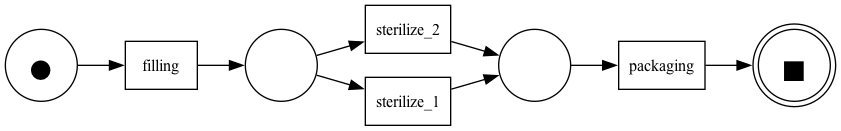

Machine objects for per-machine nets: ['M1', 'M2', 'M3', 'M4']
[machine::M1] Heuristic net: 2 places, 1 transitions, 2 arcs


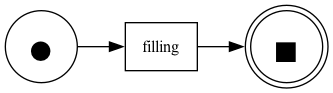

[machine::M2] Heuristic net: 6 places, 5 transitions, 10 arcs


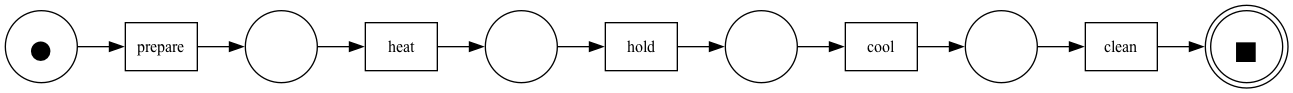

[machine::M3] Heuristic net: 6 places, 5 transitions, 10 arcs


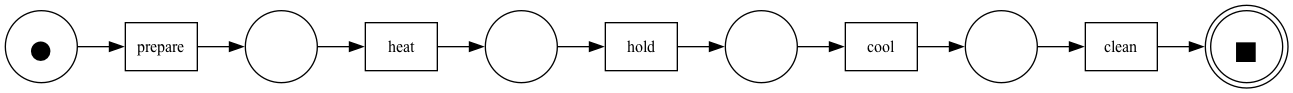

[machine::M4] Heuristic net: 2 places, 1 transitions, 2 arcs


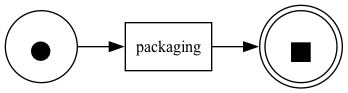

In [11]:
# Heuristics Miner Petri nets: 1 for material flow + 1 per machine
import pm4py

def mine_and_view_heuristic_net(df, label):
    df_local = df[["case_id", "activity", "timestamp_start"]].copy()
    if df_local.empty:
        print(f"[{label}] skipped: no events")
        return None
    df_local["timestamp_start"] = pd.to_datetime(df_local["timestamp_start"])

    pm_log = pm4py.format_dataframe(
        df_local,
        case_id="case_id",
        activity_key="activity",
        timestamp_key="timestamp_start",
    )
    try:
        net, im, fm = pm4py.discover_petri_net_heuristics(pm_log)
        print(
            f"[{label}] Heuristic net: "
            f"{len(net.places)} places, {len(net.transitions)} transitions, {len(net.arcs)} arcs"
        )
        pm4py.view_petri_net(net, im, fm, format="png")
        return net, im, fm
    except Exception as exc:
        print(f"[{label}] mining failed: {exc}")
        return None

# 1) Material-flow net (single process-level model)
material_log = event_log[event_log["object_type"] == "material_flow"].copy()
_ = mine_and_view_heuristic_net(material_log, "material_flow")

# 2) One machine-state net per machine object
machine_log = event_log[event_log["object_type"] == "machine_state"].copy()
machine_objects = sorted(machine_log["object"].dropna().unique().tolist())
print(f"Machine objects for per-machine nets: {machine_objects}")

for machine_name in machine_objects:
    machine_df = machine_log[machine_log["object"] == machine_name].copy()
    _ = mine_and_view_heuristic_net(machine_df, f"machine::{machine_name}")

[material_flow] DFG: 4 edges, 1 start activities, 1 end activities


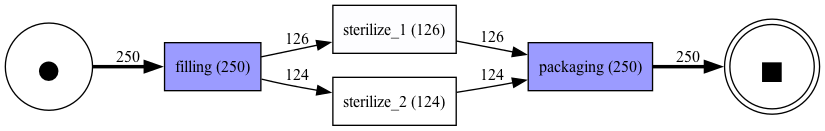

Machine objects for per-machine DFGs: ['M1', 'M2', 'M3', 'M4']
[machine::M1] DFG: 0 edges, 1 start activities, 1 end activities
[machine::M1] no directly-follows edges to visualize (single-activity trace set).
[machine::M2] DFG: 4 edges, 1 start activities, 1 end activities


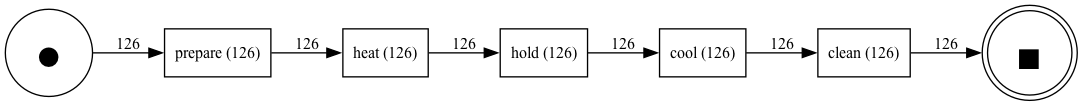

[machine::M3] DFG: 4 edges, 1 start activities, 1 end activities


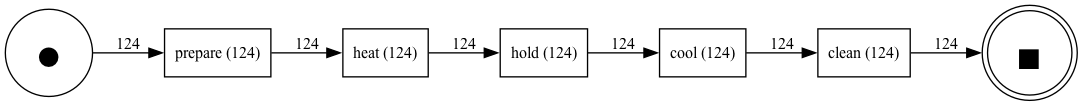

[machine::M4] DFG: 0 edges, 1 start activities, 1 end activities
[machine::M4] no directly-follows edges to visualize (single-activity trace set).


In [12]:
# Directed Follows Graphs (DFG) - no Petri net
import pm4py

def view_dfg_for_subset(df, label):
    if df.empty:
        print(f"[{label}] skipped: no events")
        return
    local = df[["case_id", "activity", "timestamp_start"]].copy()
    local["timestamp_start"] = pd.to_datetime(local["timestamp_start"])

    pm_local = pm4py.format_dataframe(
        local,
        case_id="case_id",
        activity_key="activity",
        timestamp_key="timestamp_start",
    )
    dfg, starts, ends = pm4py.discover_dfg(pm_local)
    print(
        f"[{label}] DFG: {len(dfg)} edges, "
        f"{len(starts)} start activities, {len(ends)} end activities"
    )

    # Some machine logs have only one repeated activity, so DFG has zero edges.
    if len(dfg) == 0:
        print(f"[{label}] no directly-follows edges to visualize (single-activity trace set).")
        return

    pm4py.view_dfg(
        dfg,
        starts,
        ends,
        format="png",
    )

# 1) Process-level DFG (material flow)
material_log = event_log[event_log["object_type"] == "material_flow"].copy()
view_dfg_for_subset(material_log, "material_flow")

# 2) Per-machine DFGs (machine states)
machine_log = event_log[event_log["object_type"] == "machine_state"].copy()
machine_objects = sorted(machine_log["object"].dropna().unique().tolist())
print(f"Machine objects for per-machine DFGs: {machine_objects}")
for machine_name in machine_objects:
    machine_df = machine_log[machine_log["object"] == machine_name].copy()
    view_dfg_for_subset(machine_df, f"machine::{machine_name}")

In [13]:
material_log.columns

Index(['case_id', 'activity', 'timestamp_start', 'timestamp_end', 'object',
       'object_type', 'higher_level_activity', 'object_attributes'],
      dtype='object')

In [14]:
material_log = event_log[event_log["object_type"] == "material_flow"].copy()

# Expand object_attributes into regular columns to avoid NaN dict rendering
attrs_cols = pd.json_normalize(
    material_log["object_attributes"].apply(lambda x: x if isinstance(x, dict) else {})
).add_prefix("attr_")

# Keep legacy typo and canonical key aligned
if "attr_type_package" not in attrs_cols.columns and "attr_type_pacakge" in attrs_cols.columns:
    attrs_cols["attr_type_package"] = attrs_cols["attr_type_pacakge"]
if "attr_type_pacakge" not in attrs_cols.columns and "attr_type_package" in attrs_cols.columns:
    attrs_cols["attr_type_pacakge"] = attrs_cols["attr_type_package"]

# Timestamps shown only until seconds
result_table = material_log[[
    "case_id", "activity", "timestamp_start", "timestamp_end", "object", "object_type"
 ]].copy()
result_table["timestamp_start"] = pd.to_datetime(result_table["timestamp_start"]).dt.strftime("%Y-%m-%d %H:%M:%S")
result_table["timestamp_end"] = pd.to_datetime(result_table["timestamp_end"]).dt.strftime("%Y-%m-%d %H:%M:%S")

attribute_cols = ["attr_batch_size", "attr_liquid_density", "attr_type_package", "attr_variant"]
for col in attribute_cols:
    if col not in attrs_cols.columns:
        attrs_cols[col] = pd.NA

result_table = pd.concat([
    result_table.reset_index(drop=True),
    attrs_cols[attribute_cols].reset_index(drop=True),
], axis=1)

display(result_table.head(40))

# Create LaTeX-safe table (escape underscores in headers and string values)
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]
for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].astype(str).str.replace("_", r"\_", regex=False)

# Print LaTeX output
latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,timestamp_start,timestamp_end,object,object_type,attr_batch_size,attr_liquid_density,attr_type_package,attr_variant
0,batch_0001,filling,2026-01-01 06:00:00,2026-01-01 06:14:08,material_flow,material_flow,1254,0.9988,B,A
1,batch_0001,sterilize_1,2026-01-01 06:14:08,2026-01-01 07:18:52,material_flow,material_flow,1254,0.9988,B,A
2,batch_0002,filling,2026-01-01 06:14:08,2026-01-01 06:31:34,material_flow,material_flow,965,1.0338,B,B
3,batch_0002,sterilize_2,2026-01-01 06:31:34,2026-01-01 07:38:09,material_flow,material_flow,965,1.0338,B,B
4,batch_0003,filling,2026-01-01 06:31:34,2026-01-01 06:54:12,material_flow,material_flow,1046,1.0564,B,A
5,batch_0004,filling,2026-01-01 06:54:12,2026-01-01 07:13:08,material_flow,material_flow,1077,1.0667,B,B
6,batch_0005,filling,2026-01-01 07:13:08,2026-01-01 07:32:48,material_flow,material_flow,1265,1.0424,B,A
7,batch_0001,packaging,2026-01-01 07:18:52,2026-01-01 07:32:13,material_flow,material_flow,1254,0.9988,B,A
8,batch_0004,sterilize_1,2026-01-01 07:18:52,2026-01-01 08:26:52,material_flow,material_flow,1077,1.0667,B,B
9,batch_0006,filling,2026-01-01 07:32:48,2026-01-01 07:55:25,material_flow,material_flow,1107,1.0056,A,B


\begin{tabular}{llllllrrll}
\toprule
case\_id & activity & timestamp\_start & timestamp\_end & object & object\_type & attr\_batch\_size & attr\_liquid\_density & attr\_type\_package & attr\_variant \\
\midrule
batch\_0001 & filling & 2026-01-01 06:00:00 & 2026-01-01 06:14:08 & material\_flow & material\_flow & 1254 & 0.998800 & B & A \\
batch\_0001 & sterilize\_1 & 2026-01-01 06:14:08 & 2026-01-01 07:18:52 & material\_flow & material\_flow & 1254 & 0.998800 & B & A \\
batch\_0002 & filling & 2026-01-01 06:14:08 & 2026-01-01 06:31:34 & material\_flow & material\_flow & 965 & 1.033800 & B & B \\
batch\_0002 & sterilize\_2 & 2026-01-01 06:31:34 & 2026-01-01 07:38:09 & material\_flow & material\_flow & 965 & 1.033800 & B & B \\
batch\_0003 & filling & 2026-01-01 06:31:34 & 2026-01-01 06:54:12 & material\_flow & material\_flow & 1046 & 1.056400 & B & A \\
batch\_0004 & filling & 2026-01-01 06:54:12 & 2026-01-01 07:13:08 & material\_flow & material\_flow & 1077 & 1.066700 & B & B \\
batch\_

In [15]:
material_log = event_log[event_log["object_type"] == "material_flow"].copy()

# Expand object_attributes into regular columns to avoid NaN dict rendering
attrs_cols = pd.json_normalize(
    material_log["object_attributes"].apply(lambda x: x if isinstance(x, dict) else {})
).add_prefix("attr_")

# Keep legacy typo and canonical key aligned
if "attr_type_package" not in attrs_cols.columns and "attr_type_pacakge" in attrs_cols.columns:
    attrs_cols["attr_type_package"] = attrs_cols["attr_type_pacakge"]
if "attr_type_pacakge" not in attrs_cols.columns and "attr_type_package" in attrs_cols.columns:
    attrs_cols["attr_type_pacakge"] = attrs_cols["attr_type_package"]

# Timestamps shown only until seconds
result_table = material_log[[
    "case_id", "activity", "timestamp_start", "timestamp_end", "object", "object_type"
 ]].copy()

result_table["timestamp_start"] = pd.to_datetime(result_table["timestamp_start"]).dt.strftime("%Y-%m-%d %H:%M:%S")
result_table["timestamp_end"] = pd.to_datetime(result_table["timestamp_end"]).dt.strftime("%Y-%m-%d %H:%M:%S")

attribute_cols = ["attr_batch_size", "attr_liquid_density", "attr_type_package", "attr_variant"]
for col in attribute_cols:
    if col not in attrs_cols.columns:
        attrs_cols[col] = pd.NA

result_table = pd.concat([
    result_table.reset_index(drop=True),
    attrs_cols[attribute_cols].reset_index(drop=True),
], axis=1)

display(result_table.head(40))

# Create LaTeX-safe table (escape underscores in headers and string values)
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]
for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].astype(str).str.replace("_", r"\_", regex=False)

# Print LaTeX output
latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,timestamp_start,timestamp_end,object,object_type,attr_batch_size,attr_liquid_density,attr_type_package,attr_variant
0,batch_0001,filling,2026-01-01 06:00:00,2026-01-01 06:14:08,material_flow,material_flow,1254,0.9988,B,A
1,batch_0001,sterilize_1,2026-01-01 06:14:08,2026-01-01 07:18:52,material_flow,material_flow,1254,0.9988,B,A
2,batch_0002,filling,2026-01-01 06:14:08,2026-01-01 06:31:34,material_flow,material_flow,965,1.0338,B,B
3,batch_0002,sterilize_2,2026-01-01 06:31:34,2026-01-01 07:38:09,material_flow,material_flow,965,1.0338,B,B
4,batch_0003,filling,2026-01-01 06:31:34,2026-01-01 06:54:12,material_flow,material_flow,1046,1.0564,B,A
5,batch_0004,filling,2026-01-01 06:54:12,2026-01-01 07:13:08,material_flow,material_flow,1077,1.0667,B,B
6,batch_0005,filling,2026-01-01 07:13:08,2026-01-01 07:32:48,material_flow,material_flow,1265,1.0424,B,A
7,batch_0001,packaging,2026-01-01 07:18:52,2026-01-01 07:32:13,material_flow,material_flow,1254,0.9988,B,A
8,batch_0004,sterilize_1,2026-01-01 07:18:52,2026-01-01 08:26:52,material_flow,material_flow,1077,1.0667,B,B
9,batch_0006,filling,2026-01-01 07:32:48,2026-01-01 07:55:25,material_flow,material_flow,1107,1.0056,A,B


\begin{tabular}{llllllrrll}
\toprule
case\_id & activity & timestamp\_start & timestamp\_end & object & object\_type & attr\_batch\_size & attr\_liquid\_density & attr\_type\_package & attr\_variant \\
\midrule
batch\_0001 & filling & 2026-01-01 06:00:00 & 2026-01-01 06:14:08 & material\_flow & material\_flow & 1254 & 0.998800 & B & A \\
batch\_0001 & sterilize\_1 & 2026-01-01 06:14:08 & 2026-01-01 07:18:52 & material\_flow & material\_flow & 1254 & 0.998800 & B & A \\
batch\_0002 & filling & 2026-01-01 06:14:08 & 2026-01-01 06:31:34 & material\_flow & material\_flow & 965 & 1.033800 & B & B \\
batch\_0002 & sterilize\_2 & 2026-01-01 06:31:34 & 2026-01-01 07:38:09 & material\_flow & material\_flow & 965 & 1.033800 & B & B \\
batch\_0003 & filling & 2026-01-01 06:31:34 & 2026-01-01 06:54:12 & material\_flow & material\_flow & 1046 & 1.056400 & B & A \\
batch\_0004 & filling & 2026-01-01 06:54:12 & 2026-01-01 07:13:08 & material\_flow & material\_flow & 1077 & 1.066700 & B & B \\
batch\_

In [16]:
material_log = event_log[event_log["object_type"] == "material_flow"].copy()

# Expand object_attributes into regular columns to avoid NaN dict rendering
attrs_cols = pd.json_normalize(
    material_log["object_attributes"].apply(lambda x: x if isinstance(x, dict) else {})
).add_prefix("attr_")

# Keep legacy typo and canonical key aligned
if "attr_type_package" not in attrs_cols.columns and "attr_type_pacakge" in attrs_cols.columns:
    attrs_cols["attr_type_package"] = attrs_cols["attr_type_pacakge"]
if "attr_type_pacakge" not in attrs_cols.columns and "attr_type_package" in attrs_cols.columns:
    attrs_cols["attr_type_pacakge"] = attrs_cols["attr_type_package"]

# Timestamps shown only until seconds
result_table = material_log[[
    "case_id", "activity", "timestamp_start", "timestamp_end"
 ]].copy()

result_table["timestamp_start"] = pd.to_datetime(result_table["timestamp_start"]).dt.strftime("%Y-%m-%d %H:%M:%S")
result_table["timestamp_end"] = pd.to_datetime(result_table["timestamp_end"]).dt.strftime("%Y-%m-%d %H:%M:%S")

attribute_cols = ["attr_variant"]
for col in attribute_cols:
    if col not in attrs_cols.columns:
        attrs_cols[col] = pd.NA

result_table = pd.concat([
    result_table.reset_index(drop=True),
    attrs_cols[attribute_cols].reset_index(drop=True),
], axis=1)

display(result_table.head(40))

# Create LaTeX-safe table (escape underscores in headers and string values)
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]
for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].astype(str).str.replace("_", r"\_", regex=False)

# Print LaTeX output
latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,timestamp_start,timestamp_end,attr_variant
0,batch_0001,filling,2026-01-01 06:00:00,2026-01-01 06:14:08,A
1,batch_0001,sterilize_1,2026-01-01 06:14:08,2026-01-01 07:18:52,A
2,batch_0002,filling,2026-01-01 06:14:08,2026-01-01 06:31:34,B
3,batch_0002,sterilize_2,2026-01-01 06:31:34,2026-01-01 07:38:09,B
4,batch_0003,filling,2026-01-01 06:31:34,2026-01-01 06:54:12,A
5,batch_0004,filling,2026-01-01 06:54:12,2026-01-01 07:13:08,B
6,batch_0005,filling,2026-01-01 07:13:08,2026-01-01 07:32:48,A
7,batch_0001,packaging,2026-01-01 07:18:52,2026-01-01 07:32:13,A
8,batch_0004,sterilize_1,2026-01-01 07:18:52,2026-01-01 08:26:52,B
9,batch_0006,filling,2026-01-01 07:32:48,2026-01-01 07:55:25,B


\begin{tabular}{lllll}
\toprule
case\_id & activity & timestamp\_start & timestamp\_end & attr\_variant \\
\midrule
batch\_0001 & filling & 2026-01-01 06:00:00 & 2026-01-01 06:14:08 & A \\
batch\_0001 & sterilize\_1 & 2026-01-01 06:14:08 & 2026-01-01 07:18:52 & A \\
batch\_0002 & filling & 2026-01-01 06:14:08 & 2026-01-01 06:31:34 & B \\
batch\_0002 & sterilize\_2 & 2026-01-01 06:31:34 & 2026-01-01 07:38:09 & B \\
batch\_0003 & filling & 2026-01-01 06:31:34 & 2026-01-01 06:54:12 & A \\
batch\_0004 & filling & 2026-01-01 06:54:12 & 2026-01-01 07:13:08 & B \\
batch\_0005 & filling & 2026-01-01 07:13:08 & 2026-01-01 07:32:48 & A \\
batch\_0001 & packaging & 2026-01-01 07:18:52 & 2026-01-01 07:32:13 & A \\
batch\_0004 & sterilize\_1 & 2026-01-01 07:18:52 & 2026-01-01 08:26:52 & B \\
batch\_0006 & filling & 2026-01-01 07:32:48 & 2026-01-01 07:55:25 & B \\
batch\_0002 & packaging & 2026-01-01 07:38:09 & 2026-01-01 07:54:31 & B \\
batch\_0003 & sterilize\_2 & 2026-01-01 07:38:09 & 2026-01-01 

In [17]:
material_log = event_log[event_log["object_type"] == "material_flow"].copy()

# Expand object_attributes into columns
attrs_cols = pd.json_normalize(
    material_log["object_attributes"].apply(lambda x: x if isinstance(x, dict) else {})
).add_prefix("attr_")

# Ensure attribute column exists
if "attr_variant" not in attrs_cols.columns:
    attrs_cols["attr_variant"] = pd.NA

# Build result table with required columns
result_table = material_log[["case_id", "activity", "timestamp_start"]].copy()

# Format timestamp
result_table["timestamp_start"] = pd.to_datetime(
    result_table["timestamp_start"]
).dt.strftime("%Y-%m-%d %H:%M")

# Keep only last 3 digits of case_id
result_table["case_id"] = result_table["case_id"].astype(str).str[-3:]

# Add attribute column
result_table["attribute"] = attrs_cols["attr_variant"].values

display(result_table.head(40))

# LaTeX export
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]

for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].astype(str).str.replace("_", r"\_", regex=False)

latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,timestamp_start,attribute
0,001,filling,2026-01-01 06:00,A
3,001,sterilize_1,2026-01-01 06:14,A
4,002,filling,2026-01-01 06:14,B
8,002,sterilize_2,2026-01-01 06:31,B
9,003,filling,2026-01-01 06:31,A
13,004,filling,2026-01-01 06:54,B
17,005,filling,2026-01-01 07:13,A
20,001,packaging,2026-01-01 07:18,A
23,004,sterilize_1,2026-01-01 07:18,B
26,006,filling,2026-01-01 07:32,B


\begin{tabular}{llll}
\toprule
case\_id & activity & timestamp\_start & attribute \\
\midrule
001 & filling & 2026-01-01 06:00 & A \\
001 & sterilize\_1 & 2026-01-01 06:14 & A \\
002 & filling & 2026-01-01 06:14 & B \\
002 & sterilize\_2 & 2026-01-01 06:31 & B \\
003 & filling & 2026-01-01 06:31 & A \\
004 & filling & 2026-01-01 06:54 & B \\
005 & filling & 2026-01-01 07:13 & A \\
001 & packaging & 2026-01-01 07:18 & A \\
004 & sterilize\_1 & 2026-01-01 07:18 & B \\
006 & filling & 2026-01-01 07:32 & B \\
002 & packaging & 2026-01-01 07:38 & B \\
003 & sterilize\_2 & 2026-01-01 07:38 & A \\
007 & filling & 2026-01-01 07:55 & A \\
008 & filling & 2026-01-01 08:14 & B \\
004 & packaging & 2026-01-01 08:26 & B \\
\bottomrule
\end{tabular}



In [18]:
event_log["object"].value_counts()

object
material_flow    750
M2               630
M3               620
M1               250
M4               250
Name: count, dtype: int64

In [19]:
machine_log = event_log[
    (event_log["object_type"] == "machine_state") &
    (event_log["object"] == "M2")
].copy()

# Expand object_attributes into columns
attrs_cols = pd.json_normalize(
    machine_log["object_attributes"].apply(lambda x: x if isinstance(x, dict) else {})
).add_prefix("attr_")

# Ensure attribute column exists
if "attr_variant" not in attrs_cols.columns:
    attrs_cols["attr_variant"] = pd.NA

# Build result table with required columns
result_table = machine_log[["case_id", "activity", "timestamp_start"]].copy()

# Format timestamp
result_table["timestamp_start"] = pd.to_datetime(
    result_table["timestamp_start"]
).dt.strftime("%Y-%m-%d %H:%M")

# Keep only last 3 digits of case_id
result_table["case_id"] = result_table["case_id"].astype(str).str[-3:]

# Add attribute column
result_table["attribute"] = attrs_cols["attr_variant"].values

display(result_table.head(40))

# LaTeX export
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]

for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].astype(str).str.replace("_", r"\_", regex=False)

latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,timestamp_start,attribute
2,001,prepare,2026-01-01 06:14,A
6,001,heat,2026-01-01 06:22,A
12,001,hold,2026-01-01 06:41,A
16,001,cool,2026-01-01 07:05,A
19,001,clean,2026-01-01 07:14,A
22,004,prepare,2026-01-01 07:18,B
25,004,heat,2026-01-01 07:27,B
33,004,hold,2026-01-01 07:46,B
38,004,cool,2026-01-01 08:11,B
41,004,clean,2026-01-01 08:21,B


\begin{tabular}{llll}
\toprule
case\_id & activity & timestamp\_start & attribute \\
\midrule
001 & prepare & 2026-01-01 06:14 & A \\
001 & heat & 2026-01-01 06:22 & A \\
001 & hold & 2026-01-01 06:41 & A \\
001 & cool & 2026-01-01 07:05 & A \\
001 & clean & 2026-01-01 07:14 & A \\
004 & prepare & 2026-01-01 07:18 & B \\
004 & heat & 2026-01-01 07:27 & B \\
004 & hold & 2026-01-01 07:46 & B \\
004 & cool & 2026-01-01 08:11 & B \\
004 & clean & 2026-01-01 08:21 & B \\
005 & prepare & 2026-01-01 08:26 & A \\
005 & heat & 2026-01-01 08:34 & A \\
005 & hold & 2026-01-01 08:52 & A \\
005 & cool & 2026-01-01 09:15 & A \\
005 & clean & 2026-01-01 09:25 & A \\
\bottomrule
\end{tabular}



In [20]:
machine_log = event_log[
    (event_log["object_type"] == "machine_state") 
    #(event_log["object"] == "M2")
].copy()

# Expand object_attributes into columns
attrs_cols = pd.json_normalize(
    machine_log["object_attributes"].apply(lambda x: x if isinstance(x, dict) else {})
).add_prefix("attr_")

# Ensure attribute column exists
if "attr_variant" not in attrs_cols.columns:
    attrs_cols["attr_variant"] = pd.NA

# Build result table with required columns
result_table = machine_log[["case_id", "activity", "timestamp_start", "object"]].copy()

# Format timestamp
result_table["timestamp_start"] = pd.to_datetime(
    result_table["timestamp_start"]
).dt.strftime("%Y-%m-%d %H:%M")

# Keep only last 3 digits of case_id
result_table["case_id"] = result_table["case_id"].astype(str).str[-3:]

# Add attribute column
result_table["attribute"] = attrs_cols["attr_variant"].values

display(result_table.head(40))

# LaTeX export
latex_df = result_table.head(15).copy()
latex_df.columns = [c.replace("_", r"\_") for c in latex_df.columns]

for col in latex_df.select_dtypes(include=["object"]).columns:
    latex_df[col] = latex_df[col].astype(str).str.replace("_", r"\_", regex=False)

latex_table = latex_df.to_latex(index=False, escape=False)
print(latex_table)

,case_id,activity,timestamp_start,object,attribute
1,001,filling,2026-01-01 06:00,M1,A
2,001,prepare,2026-01-01 06:14,M2,A
5,002,filling,2026-01-01 06:14,M1,B
6,001,heat,2026-01-01 06:22,M2,A
7,002,prepare,2026-01-01 06:31,M3,B
10,003,filling,2026-01-01 06:31,M1,A
11,002,heat,2026-01-01 06:38,M3,B
12,001,hold,2026-01-01 06:41,M2,A
14,004,filling,2026-01-01 06:54,M1,B
15,002,hold,2026-01-01 06:56,M3,B


\begin{tabular}{lllll}
\toprule
case\_id & activity & timestamp\_start & object & attribute \\
\midrule
001 & filling & 2026-01-01 06:00 & M1 & A \\
001 & prepare & 2026-01-01 06:14 & M2 & A \\
002 & filling & 2026-01-01 06:14 & M1 & B \\
001 & heat & 2026-01-01 06:22 & M2 & A \\
002 & prepare & 2026-01-01 06:31 & M3 & B \\
003 & filling & 2026-01-01 06:31 & M1 & A \\
002 & heat & 2026-01-01 06:38 & M3 & B \\
001 & hold & 2026-01-01 06:41 & M2 & A \\
004 & filling & 2026-01-01 06:54 & M1 & B \\
002 & hold & 2026-01-01 06:56 & M3 & B \\
001 & cool & 2026-01-01 07:05 & M2 & A \\
005 & filling & 2026-01-01 07:13 & M1 & A \\
001 & clean & 2026-01-01 07:14 & M2 & A \\
001 & packaging & 2026-01-01 07:18 & M4 & A \\
004 & prepare & 2026-01-01 07:18 & M2 & B \\
\bottomrule
\end{tabular}

